In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.transforms import Normalize
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import math

from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

from utils_dir.backbones_utils import load_clip_to_cpu

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Embedding Analysis
Show, for vanilla CLIP vs RS CLIP:
* text embeddings for zero-shot prompt "a satellite image of a [class]"
* text embedding for the learned CoOp prompt vector (with class name)
* visual embeddings for 10-shot prototype image crops

In [55]:
dataset='mar'
N=10
M_list=[3]

#### Get text embeddings

In [56]:
# Load zeroshot prototypes
clip_zs = torch.load(f"run/text_prototypes/boxes/{dataset}/prototypes_clip-14.pt")
georsclip_zs = torch.load(f"run/text_prototypes/boxes/{dataset}/prototypes_georsclip-14.pt")
remoteclip_zs = torch.load(f"run/text_prototypes/boxes/{dataset}/prototypes_remoteclip-14.pt")

label_names = clip_zs['label_names']
clip_zs = clip_zs['prototypes']
georsclip_zs = georsclip_zs['prototypes']
remoteclip_zs = remoteclip_zs['prototypes']

# # Load CoOp prototypes
# if dataset == 'mar':
#     clip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_clip_2/prototypes_clip-14.pt")
#     georsclip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_georsclip_2/prototypes_georsclip-14.pt")
#     remoteclip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_remoteclip_2/prototypes_remoteclip-14.pt")

clip_coop = torch.stack([
    torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_clip_2/prototypes_clip-14.pt")['prototypes']
    for M in M_list
]).mean(0)

georsclip_coop = torch.stack([
    torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_georsclip_2/prototypes_georsclip-14.pt")['prototypes']
    for M in M_list
]).mean(0)

remoteclip_coop = torch.stack([
    torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_remoteclip_2/prototypes_remoteclip-14.pt")['prototypes']
    for M in M_list
]).mean(0)

In [57]:
print('Label names:', label_names)
print('Shape of prototypes:')
print(clip_zs.shape)
print(georsclip_zs.shape)
print(remoteclip_zs.shape)
print(clip_coop.shape)
print(georsclip_coop.shape)
print(remoteclip_coop.shape)

Label names: ['B-1B', 'B-52', 'C-130', 'C-17', 'C-5', 'E-3', 'E-8', 'F-15', 'F-16', 'F-22', 'FA-18', 'KC-1', 'KC-135', 'P-3C', 'SU-24', 'SU-34', 'SU-35', 'TU-160', 'TU-22', 'TU-95']
Shape of prototypes:
torch.Size([20, 768])
torch.Size([20, 768])
torch.Size([20, 768])
torch.Size([20, 768])
torch.Size([20, 768])
torch.Size([20, 768])


#### Get prototype crop embeddings

In [30]:
# Load CLIP models
clip_model = load_clip_to_cpu('clip-14')
georsclip_model = load_clip_to_cpu('georsclip-14')
remoteclip_model = load_clip_to_cpu('remoteclip-14')

in backbone utils
-> using backbone: clip-14
LOADED CLIP-14! (load_clip_to_cpu)
in backbone utils
-> using backbone: georsclip-14
LOADED GEORSCLIP-14! (load_clip_to_cpu)
in backbone utils
-> using backbone: remoteclip-14
LOADED REMOTECLIP-14! (load_clip_to_cpu)


In [6]:
PIXEL_MEAN = [0.48145466, 0.4578275, 0.40821073]
PIXEL_STD = [0.26862954, 0.26130258, 0.27577711]
coop_normalize = Normalize(mean=PIXEL_MEAN, std=PIXEL_STD)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    coop_normalize
])

def extract_embeddings(crop_path, label_names, model, transform, device="cuda"):
    crop_path = Path(crop_path)
    all_embeds = []

    with torch.no_grad():
        for label in label_names:
            img_paths = sorted((crop_path / label).glob("*.jpg"))

            images = torch.stack([
                transform(Image.open(p).convert("RGB"))
                for p in img_paths
            ]).to(device)

            feats = model.to(device).visual(images.type(model.dtype))
            feats = torch.nn.functional.normalize(feats, dim=-1)

            all_embeds.append(feats)

    return torch.stack(all_embeds)  # [num_classes, N, D]

In [58]:
# # Extract prototype image embeddings
# crop_path = f'data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}'
# clip_crop_embed = extract_embeddings(crop_path, label_names, clip_model, transform)
# georsclip_crop_embed = extract_embeddings(crop_path, label_names, georsclip_model, transform)
# remoteclip_crop_embed = extract_embeddings(crop_path, label_names, remoteclip_model, transform)
# print(clip_crop_embed.shape)
# print(georsclip_crop_embed.shape)
# print(remoteclip_crop_embed.shape)

clip_crop_embed_list = torch.cat([
    extract_embeddings(
        f"data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}",
        label_names,
        clip_model,
        transform
    )
    for M in M_list
], dim=1)
clip_crop_embed = clip_crop_embed_list.mean(1)
print(clip_crop_embed_list.shape)
print(clip_crop_embed.shape)

georsclip_crop_embed_list = torch.cat([
    extract_embeddings(
        f"data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}",
        label_names,
        georsclip_model,
        transform
    )
    for M in M_list
], dim=1)
georsclip_crop_embed = georsclip_crop_embed_list.mean(1)
print(georsclip_crop_embed_list.shape)
print(georsclip_crop_embed.shape)

remoteclip_crop_embed_list = torch.cat([
    extract_embeddings(
        f"data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}",
        label_names,
        remoteclip_model,
        transform
    )
    for M in M_list
], dim=1)
remoteclip_crop_embed = remoteclip_crop_embed_list.mean(1)
print(remoteclip_crop_embed_list.shape)
print(remoteclip_crop_embed.shape)

torch.Size([20, 10, 768])
torch.Size([20, 768])
torch.Size([20, 10, 768])
torch.Size([20, 768])
torch.Size([20, 10, 768])
torch.Size([20, 768])


#### UMAP

In [43]:
def plot_umap(text_zs, text_coop, crop_embed, title, class_names=None):
    text_zs    = text_zs.detach().cpu().float()
    text_coop  = text_coop.detach().cpu().float()
    crop_embed = crop_embed.detach().cpu().float()
    C, S, D = crop_embed.shape
    X = torch.cat([text_zs, text_coop, crop_embed.reshape(-1, D)], dim=0).numpy()
    Z = umap.UMAP(n_components=2, metric="cosine", random_state=0).fit_transform(X)
    colors = np.arange(C)
    cmap, norm = plt.get_cmap("tab20"), plt.Normalize(0, C-1)
    cls_colors = cmap(norm(colors))
    labels = class_names if class_names else [str(i) for i in range(C)]
    zs_n   = F.normalize(text_zs,   dim=-1)
    coop_n = F.normalize(text_coop, dim=-1)
    crop_n = F.normalize(crop_embed, dim=-1)
    crop_mean = crop_n.mean(dim=1)
    print('cosim')
    print(zs_n.shape)
    print(coop_n.shape)
    print(crop_n.shape)
    print(crop_mean.shape)
    sim_zs   = (zs_n   * crop_mean).sum(-1).numpy() # cosine sim
    print(sim_zs.shape)
    sim_coop = (coop_n * crop_mean).sum(-1).numpy() # cosine sim
    print(sim_coop.shape)
    delta    = sim_coop - sim_zs
    x = np.arange(C)
    
    # --- plot 1: UMAP ---
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(Z[2*C:, 0],  Z[2*C:, 1],  c=np.repeat(colors, S), cmap="tab20", vmin=0, vmax=C-1, marker=".", s=60, alpha=0.5, linewidths=0,   label="image crops")
    ax.scatter(Z[:C, 0],    Z[:C, 1],    facecolors="none", edgecolors=cls_colors, marker="*", s=40, linewidths=1.2, label="zero-shot text")
    ax.scatter(Z[C:2*C, 0], Z[C:2*C, 1], facecolors="none", edgecolors=cls_colors, marker="^", s=40, linewidths=1.2, label="CoOp text")
    # for i in range(C):
    #     ax.plot([Z[i,0], Z[C+i,0]], [Z[i,1], Z[C+i,1]], color=cls_colors[i], linewidth=0.8, alpha=0.6)
    ax.set_title(title); ax.legend(); plt.tight_layout(); plt.show()
    
    # --- plot 2: per-class alignment ---
    fig, ax = plt.subplots(figsize=(max(8, C*0.5), 4))
    ax.bar(x - 0.2, sim_zs,   0.4, label="zero-shot", alpha=0.8)
    ax.bar(x + 0.2, sim_coop, 0.4, label="CoOp",      alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("cosine sim to mean crop"); ax.legend()
    ax.set_title("Per-class text-image alignment"); plt.tight_layout(); plt.show()
    
    # --- plot 3: delta ---
    fig, ax = plt.subplots(figsize=(max(8, C*0.5), 4))
    ax.bar(x, delta, color=["green" if d > 0 else "red" for d in delta], alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("CoOp − zero-shot"); ax.set_title("Alignment delta (CoOp vs zero-shot)")
    plt.tight_layout(); plt.show()

In [14]:
def plot_umap_perclass(text_zs, text_coop, crop_embed, title, class_names=None):
    text_zs    = text_zs.detach().cpu().float()
    text_coop  = text_coop.detach().cpu().float()
    crop_embed = crop_embed.detach().cpu().float()
    C, S, D = crop_embed.shape

    ### TODO: do we need to do this?
    # normalize everything so cosine ~ euclidean distance
    text_zs_n   = F.normalize(text_zs,  dim=-1).numpy()
    text_coop_n = F.normalize(text_coop, dim=-1).numpy()
    crops_flat  = F.normalize(crop_embed.reshape(-1, D), dim=-1).numpy()

    # fit UMAP on image crops only, then project text into that space
    reducer = umap.UMAP(n_components=2, metric="cosine", random_state=0)
    Z_crops = reducer.fit_transform(crops_flat)   # (C*S, 2)
    Z_zs    = reducer.transform(text_zs_n)        # (C, 2)
    Z_coop  = reducer.transform(text_coop_n)      # (C, 2)

    # compute per-class cosine sim delta (CoOp - zero-shot vs mean crop)
    crop_n    = F.normalize(crop_embed, dim=-1)
    crop_mean = crop_n.mean(dim=1)                # (C, D)
    sim_zs    = (F.normalize(text_zs,   dim=-1) * crop_mean).sum(-1).numpy()
    sim_coop  = (F.normalize(text_coop, dim=-1) * crop_mean).sum(-1).numpy()
    delta     = sim_coop - sim_zs

    # project per-class mean crop into UMAP space
    crop_mean_n = F.normalize(crop_mean, dim=-1).numpy()   # (C, D)
    Z_crop_mean = reducer.transform(crop_mean_n)            # (C, 2)

    # map delta to red-green colormap centered at zero
    abs_max    = np.abs(delta).max()
    delta_norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
    delta_cmap = plt.get_cmap("RdYlGn")
    border_colors = [delta_cmap(delta_norm(d)) for d in delta]

    labels = class_names if class_names else [str(i) for i in range(C)]
    cmap, norm = plt.get_cmap("tab20"), plt.Normalize(0, C - 1)
    cls_colors = cmap(norm(np.arange(C)))

    # --- per-class UMAP grid ---
    ncols = min(5, C)
    nrows = math.ceil(C / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(C):
        ax = axes[i]
        # color subplot border by delta strength
        for spine in ax.spines.values():
            spine.set_edgecolor(border_colors[i])
            spine.set_linewidth(4)
        # all other classes' crops in grey for context
        other_mask = np.ones(C * S, dtype=bool)
        other_mask[i * S:(i + 1) * S] = False
        ax.scatter(Z_crops[other_mask, 0], Z_crops[other_mask, 1],
                   c="lightgrey", s=20, alpha=0.3, linewidths=0)
        # this class's crops
        ax.scatter(Z_crops[i*S:(i+1)*S, 0], Z_crops[i*S:(i+1)*S, 1],
                   c=[cls_colors[i]], s=100, alpha=0.9, linewidths=0)
        # mean of this class's crops
        ax.scatter(*Z_crop_mean[i], c="black",
                   s=100, linewidths=0, zorder=5)
        # zero-shot and coop text
        ax.scatter(*Z_zs[i],   facecolors="none", edgecolors="black",
                   marker="*", s=300, linewidths=1.5)
        ax.scatter(*Z_coop[i], facecolors="none", edgecolors="black",
                   marker="^", s=200, linewidths=1.5)
        # arrow from zero-shot -> coop
        ax.annotate("", xy=Z_coop[i], xytext=Z_zs[i],
                    arrowprops=dict(arrowstyle="->", color="black", lw=1.2))
        # title with delta colored green/red
        sign  = "+" if delta[i] >= 0 else "-"
        color = border_colors[i]
        ax.set_title(f"{labels[i]}\n", fontsize=15)
        ax.text(0.5, 1.02, f"({sign}{abs(delta[i]):.3f})",
                transform=ax.transAxes, ha="center", va="bottom",
                fontsize=15, color=color)
        ax.set_xticks([]); ax.set_yticks([])

    # hide unused subplots
    for j in range(C, len(axes)):
        axes[j].set_visible(False)

    # shared legend just below the grid
    legend_elements = [
        plt.scatter([], [], c="grey", s=60, alpha=0.9, linewidths=0, label="image crops"),
        plt.scatter([], [], c="black", s=60, linewidths=0, label="crop mean"),
        plt.scatter([], [], facecolors="none", edgecolors="black", marker="*", s=150, linewidths=1.5, label="zero-shot text"),
        plt.scatter([], [], facecolors="none", edgecolors="black", marker="^", s=100, linewidths=1.5, label="CoOp text"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=4,
               fontsize=15, frameon=True, bbox_to_anchor=(0.5, 0))
    fig.suptitle(title, fontsize=18, y=0.99)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.04, top=0.93)
    plt.show()

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cosim
torch.Size([20, 768])
torch.Size([20, 768])
torch.Size([20, 10, 768])
torch.Size([20, 768])
(20,)
(20,)


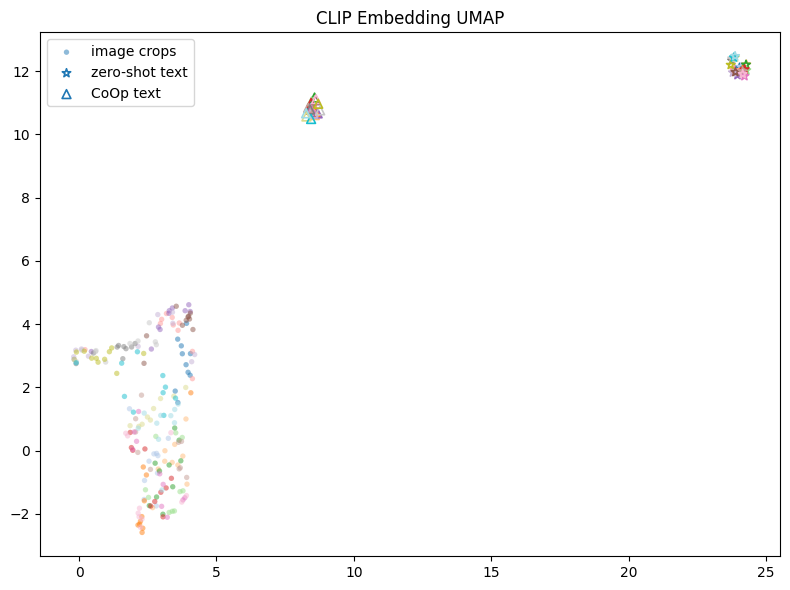

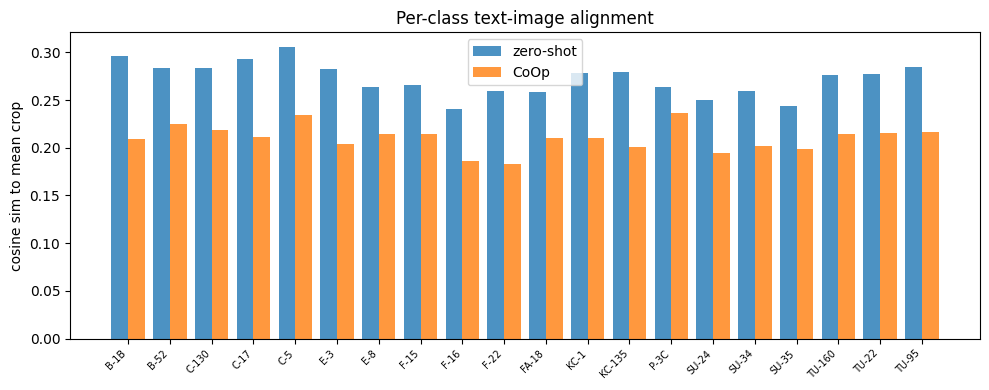

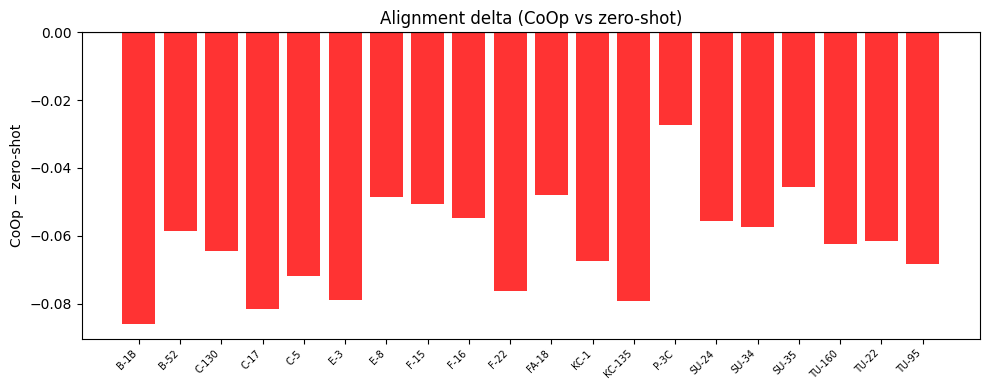

In [59]:
plot_umap(
    clip_zs,
    clip_coop,
    clip_crop_embed_list,
    "CLIP Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


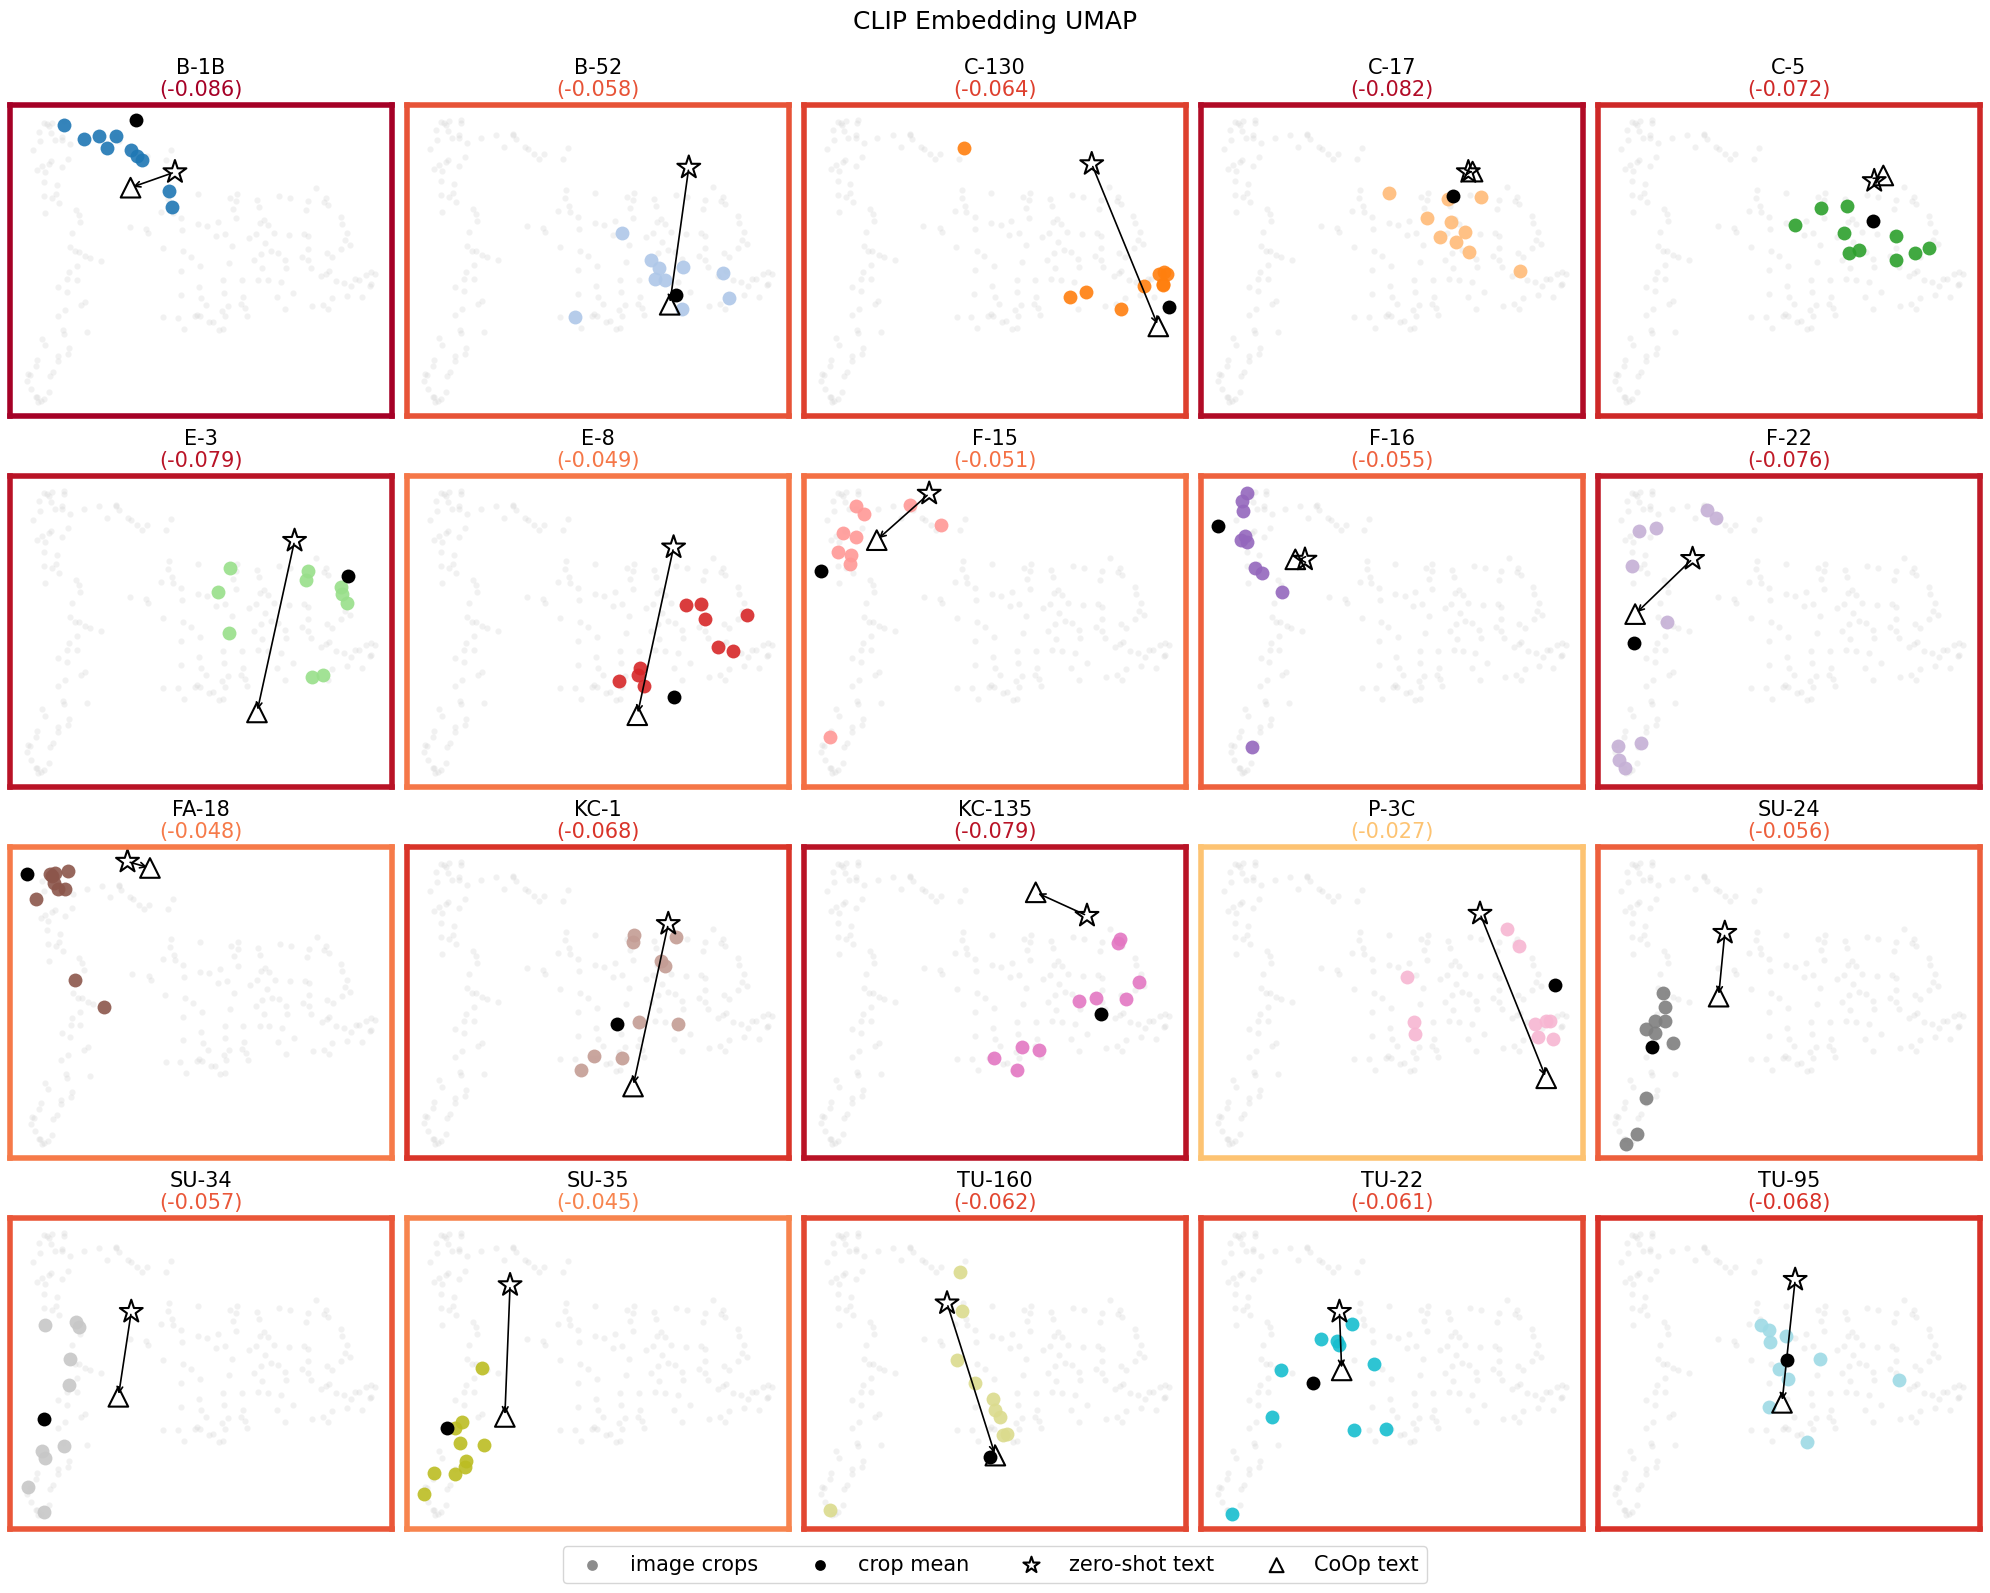

In [60]:
plot_umap_perclass(
    clip_zs,
    clip_coop,
    clip_crop_embed_list,
    "CLIP Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cosim
torch.Size([20, 768])
torch.Size([20, 768])
torch.Size([20, 10, 768])
torch.Size([20, 768])
(20,)
(20,)


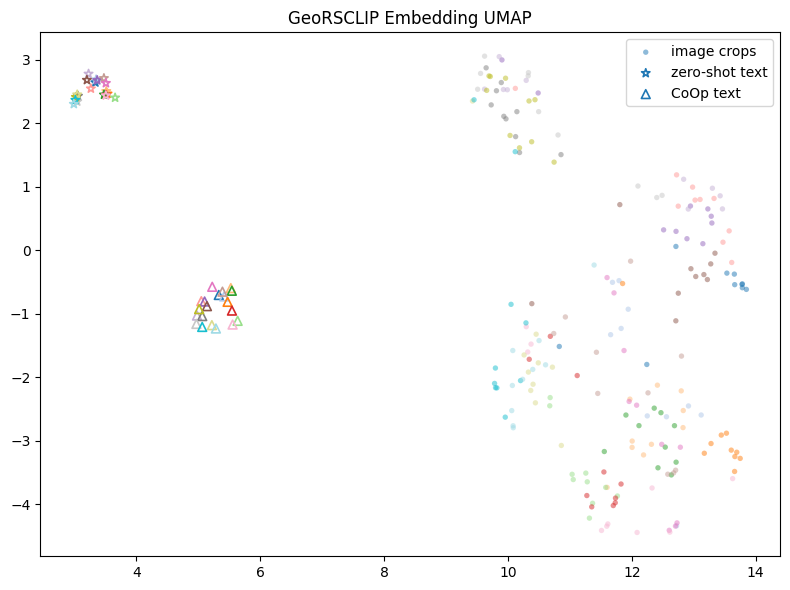

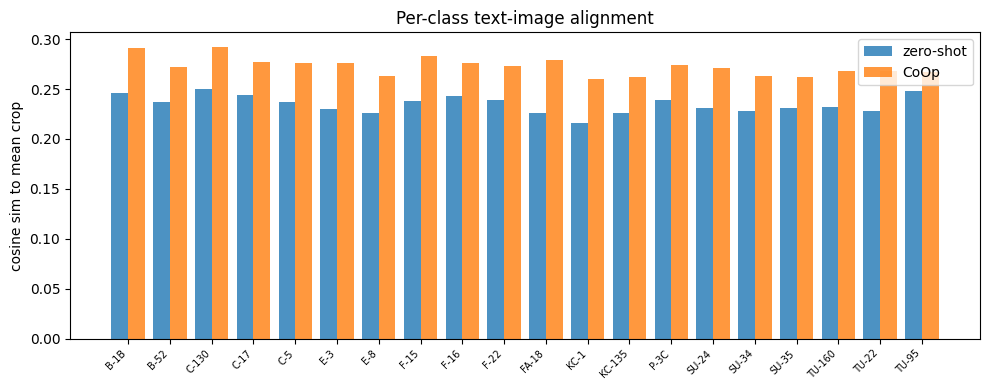

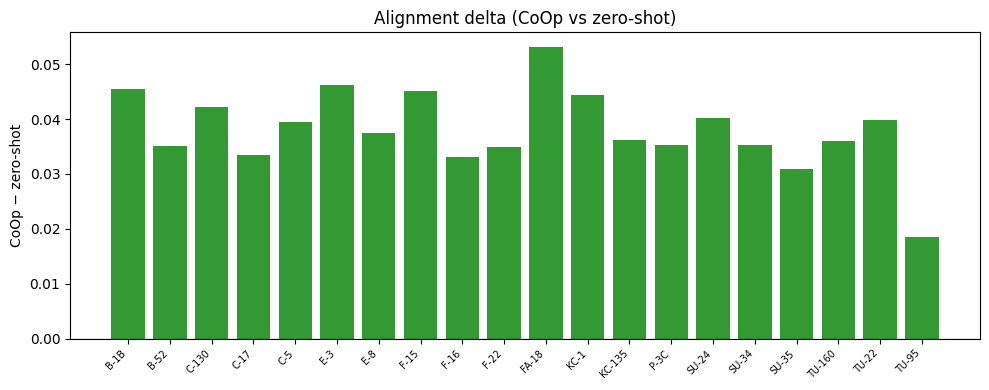

In [61]:
plot_umap(
    georsclip_zs,
    georsclip_coop,
    georsclip_crop_embed_list,
    "GeoRSCLIP Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


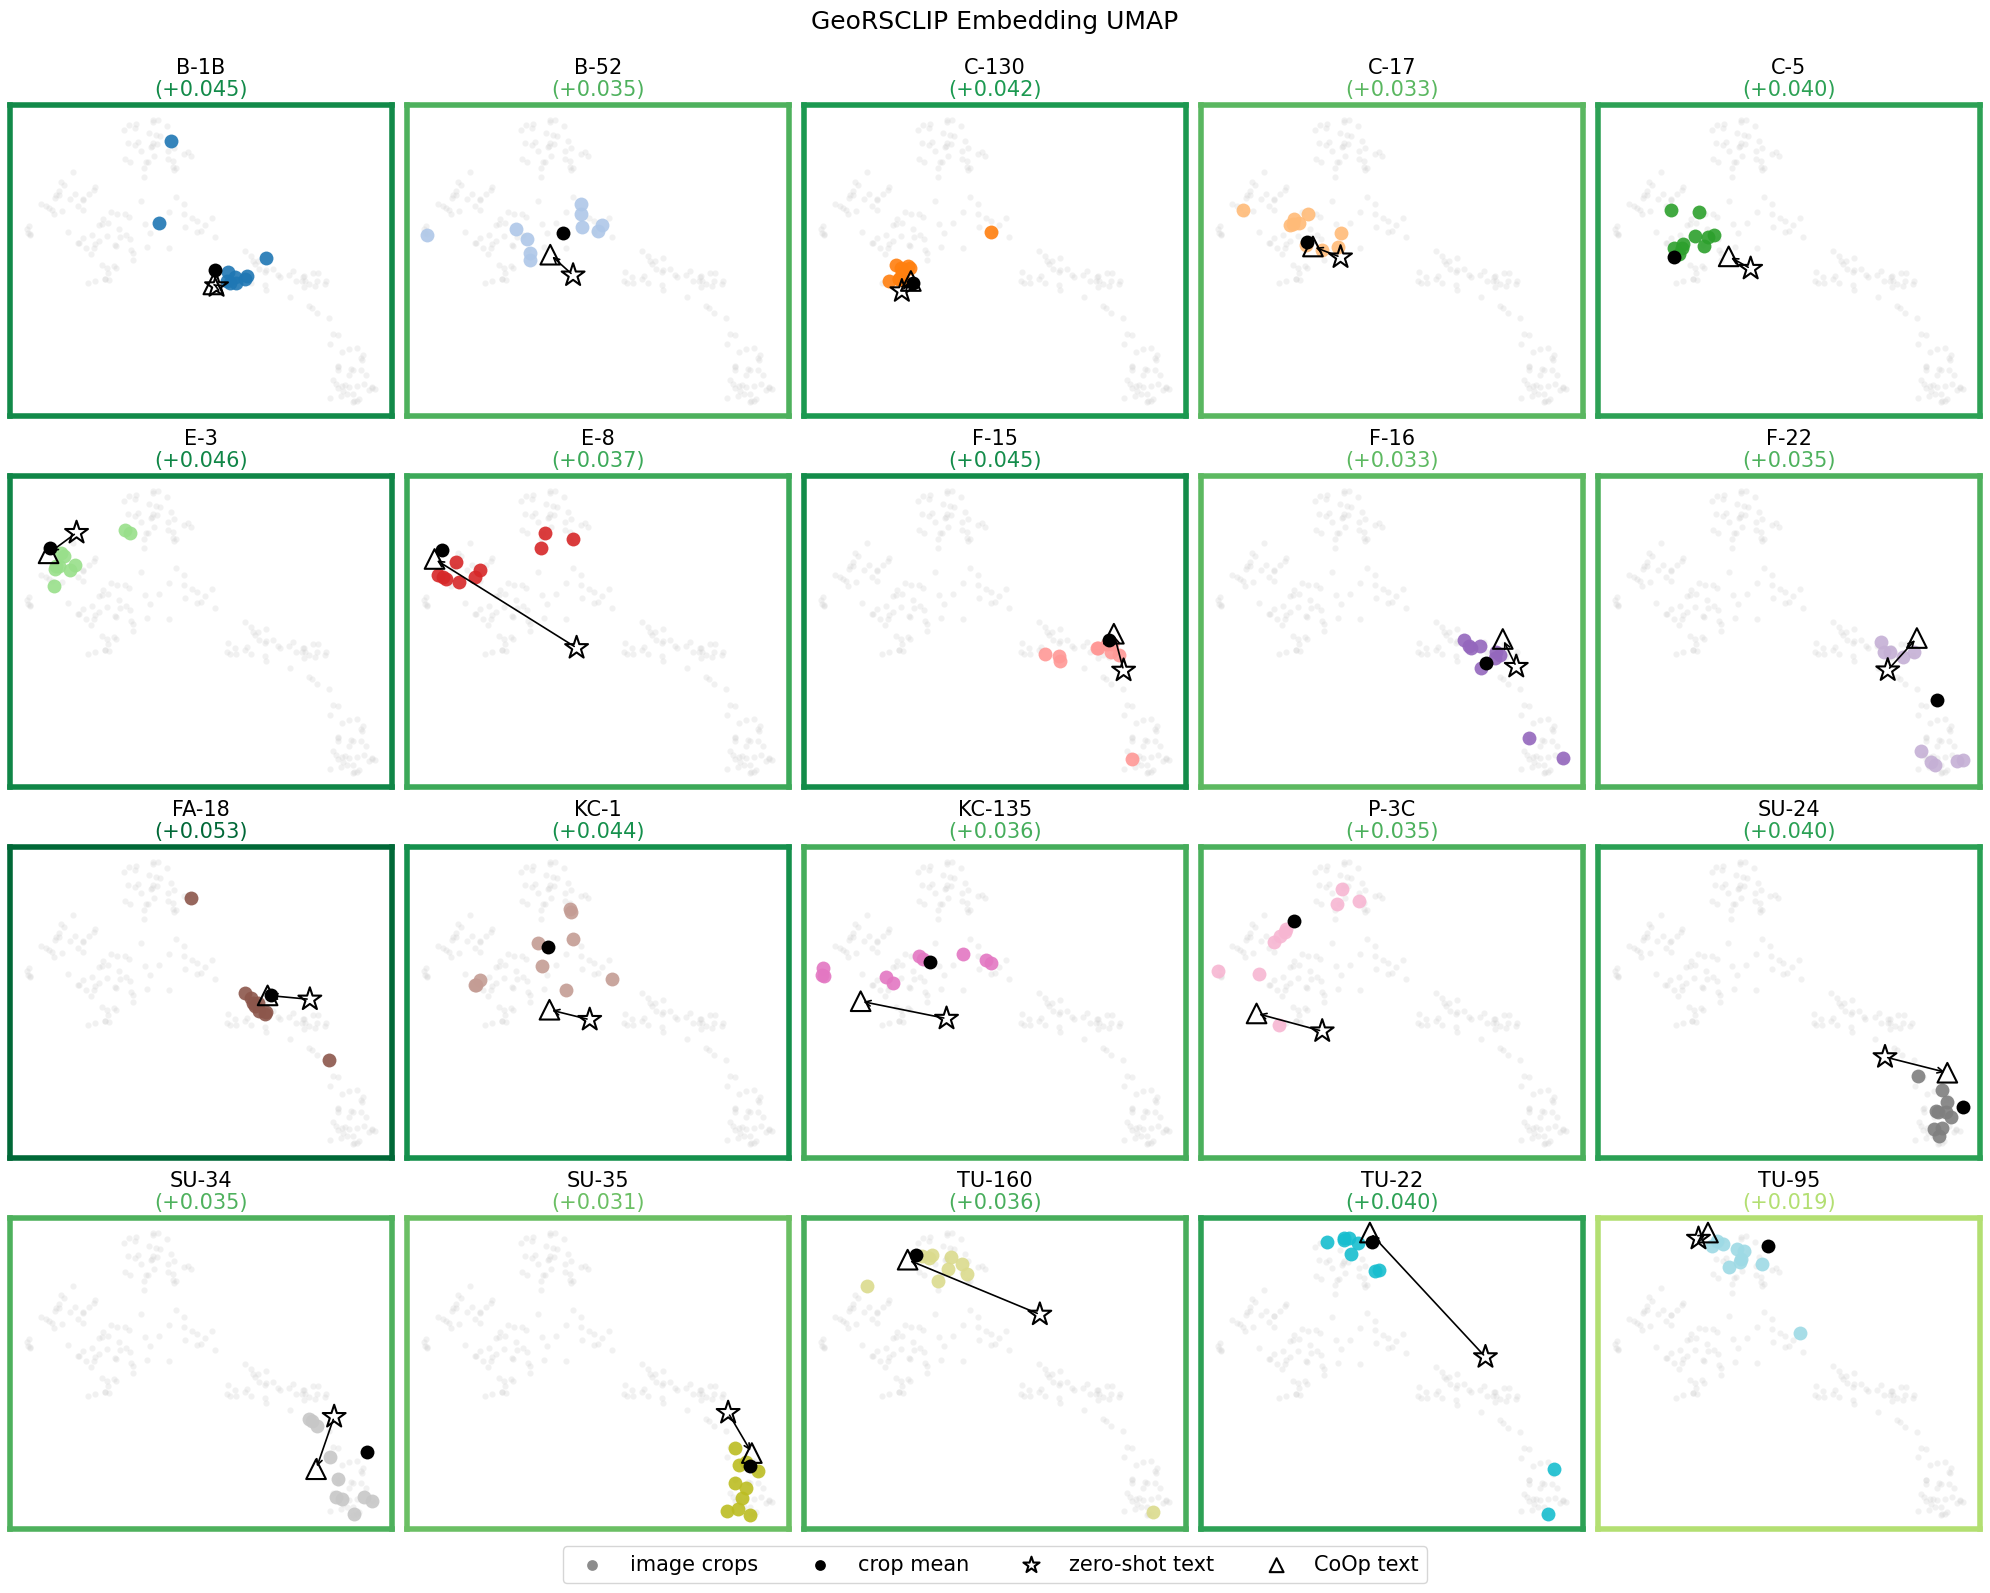

In [62]:
plot_umap_perclass(
    georsclip_zs,
    georsclip_coop,
    georsclip_crop_embed_list,
    "GeoRSCLIP Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cosim
torch.Size([20, 768])
torch.Size([20, 768])
torch.Size([20, 10, 768])
torch.Size([20, 768])
(20,)
(20,)


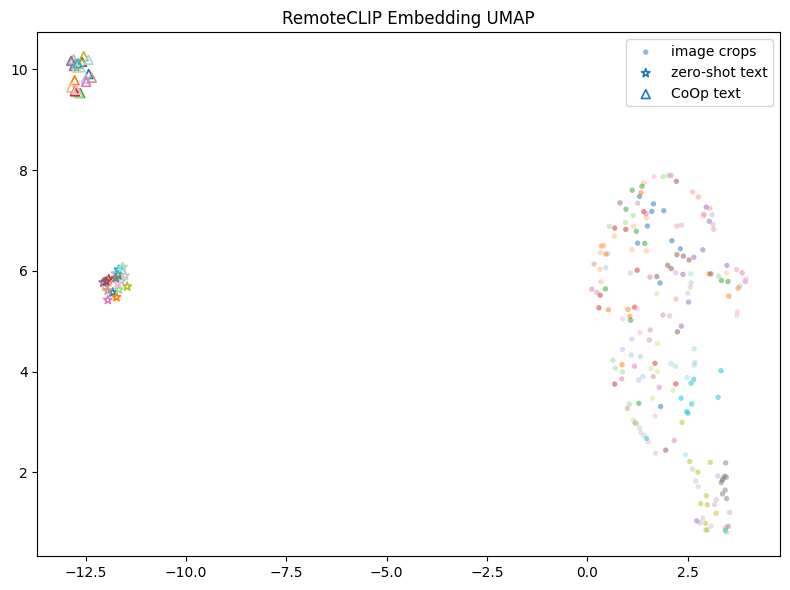

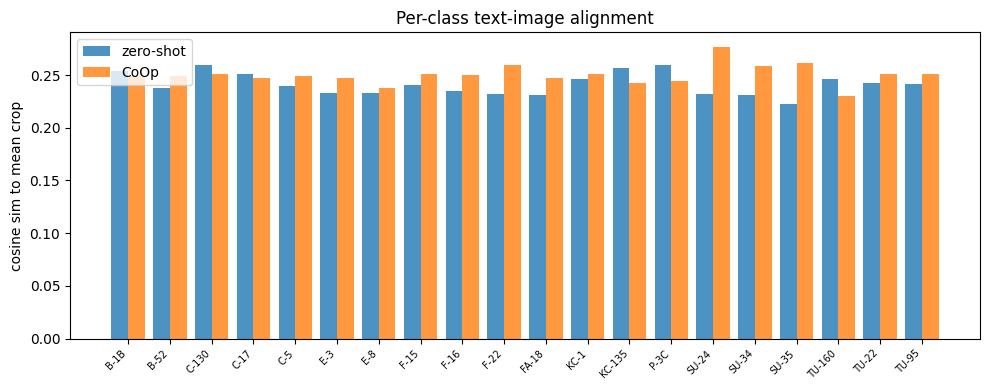

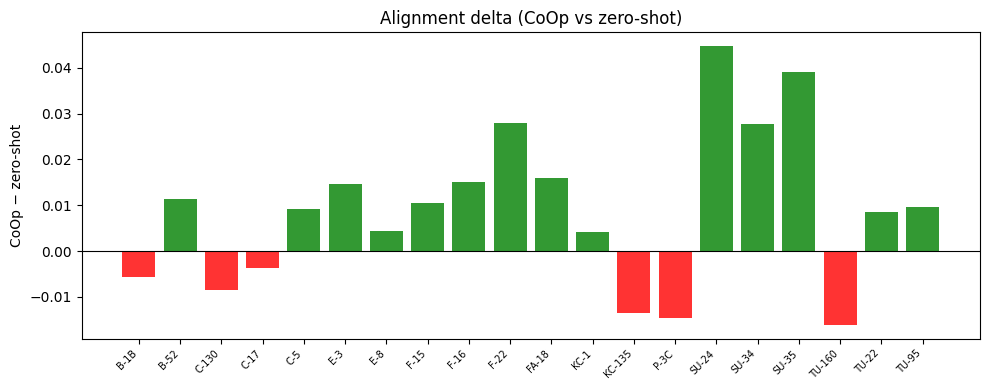

In [63]:
plot_umap(
    remoteclip_zs,
    remoteclip_coop,
    remoteclip_crop_embed_list,
    "RemoteCLIP Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


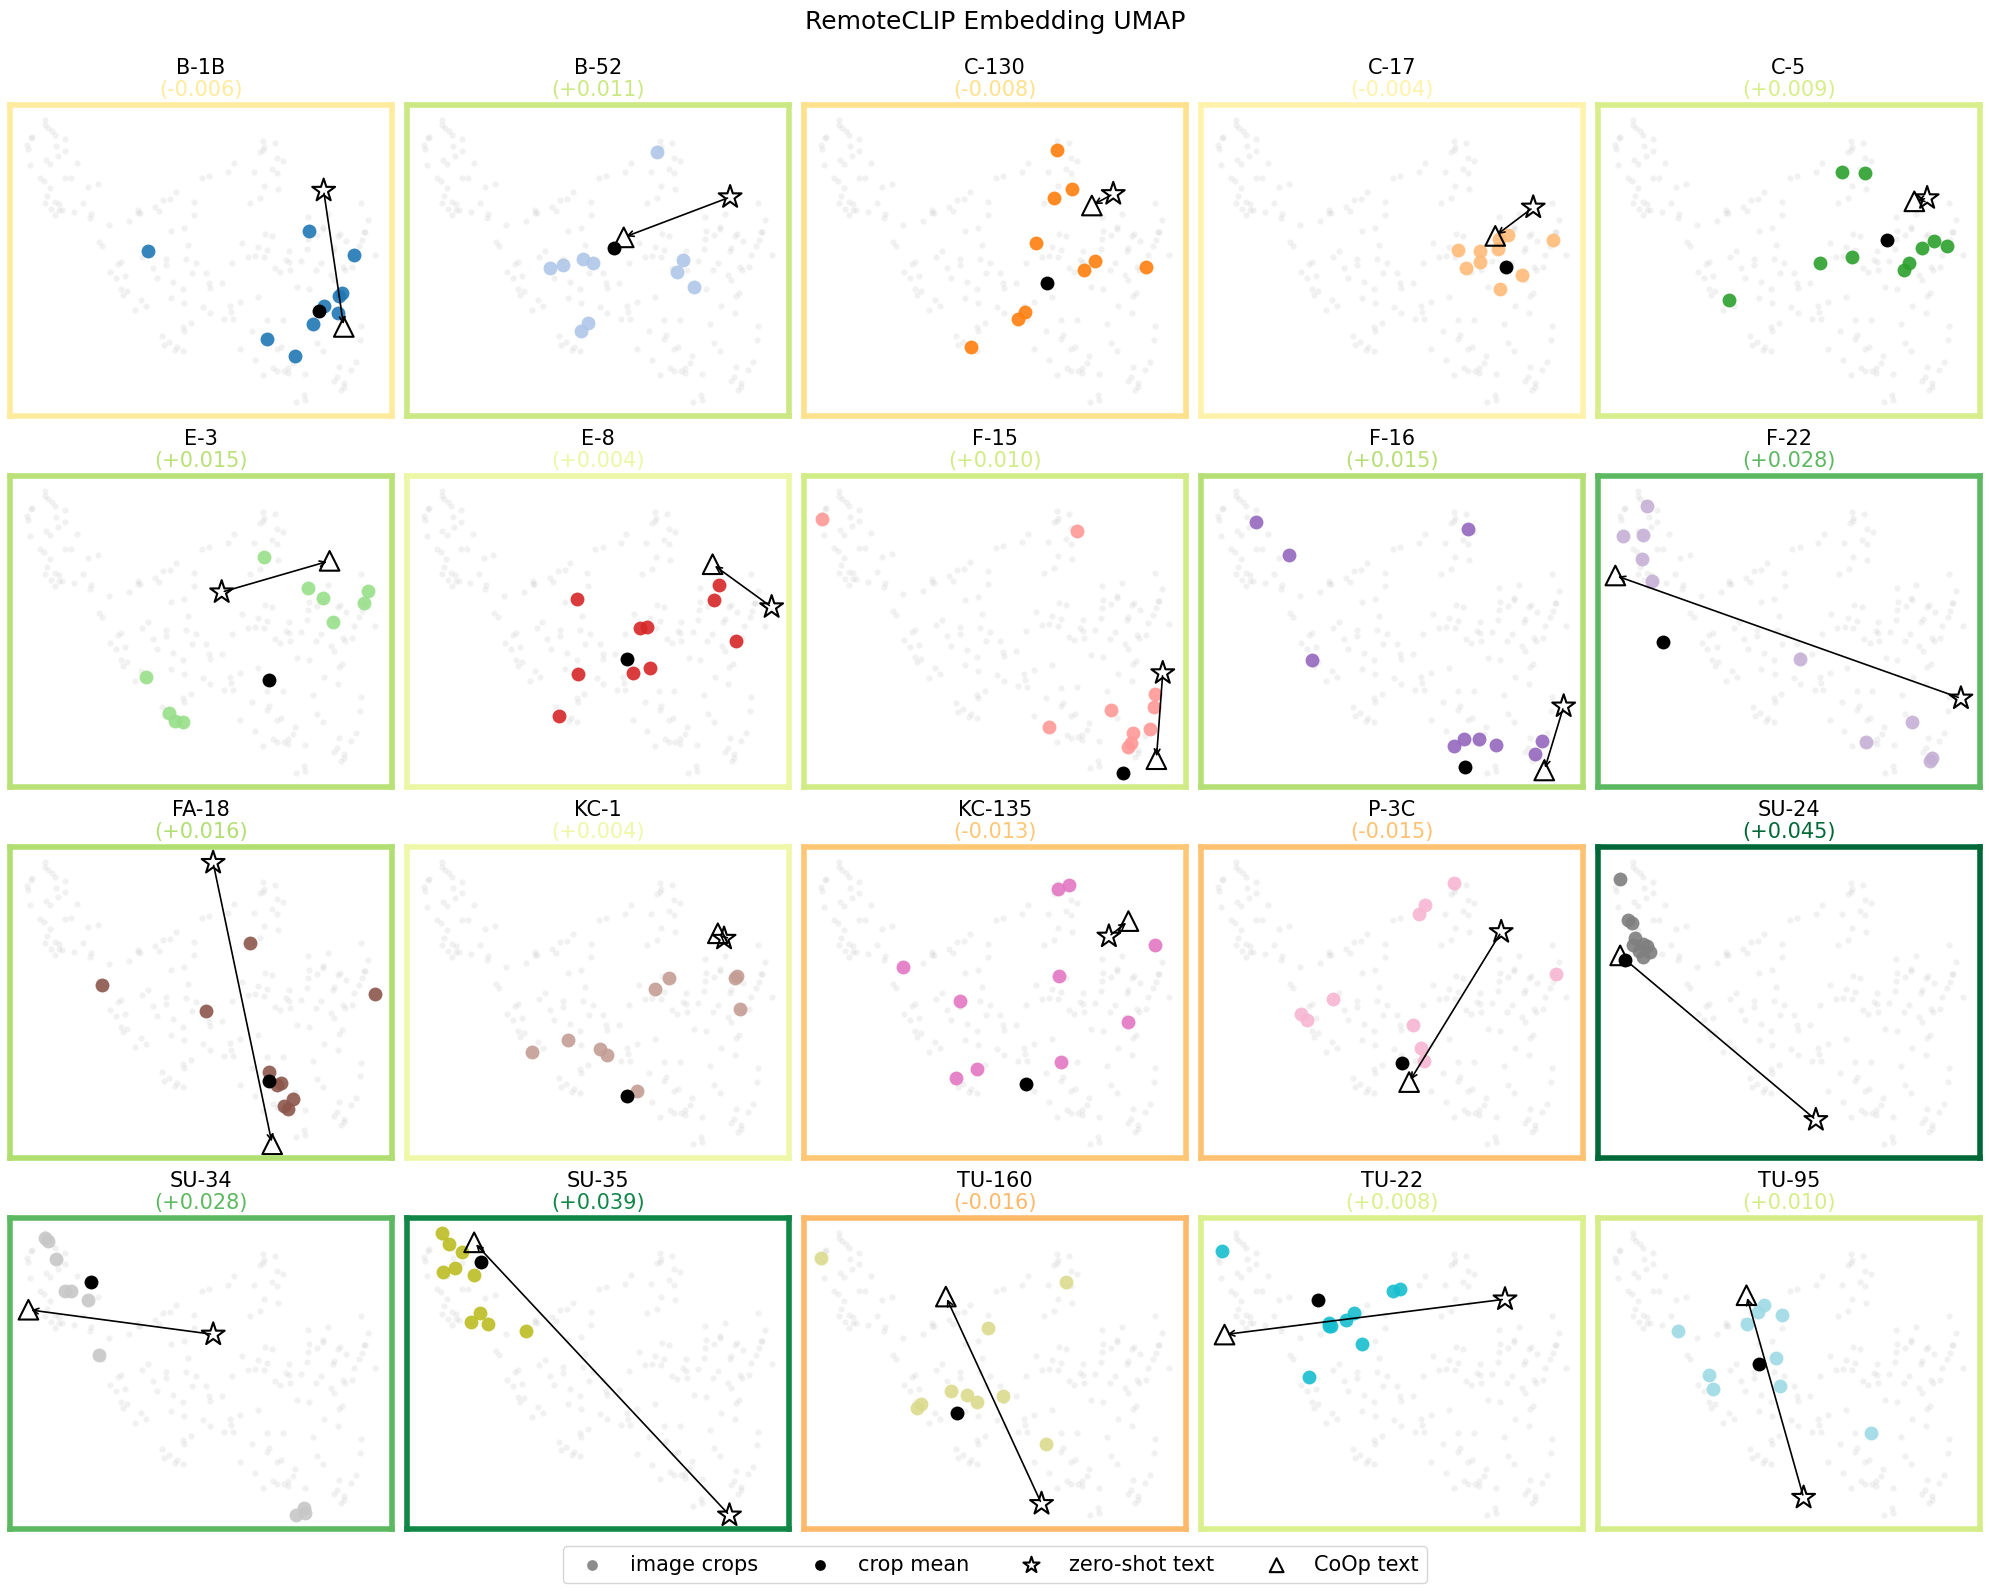

In [64]:
plot_umap_perclass(
    remoteclip_zs,
    remoteclip_coop,
    remoteclip_crop_embed_list,
    "RemoteCLIP Embedding UMAP",
    label_names
)

In [67]:
from scipy.spatial import ConvexHull

def plot_umap_crops(crop_embed, title, class_names=None):
    crop_embed = crop_embed.detach().cpu().float()
    C, S, D = crop_embed.shape

    Z = umap.UMAP(n_components=2, metric="cosine", random_state=0).fit_transform(crop_embed.reshape(-1, D).numpy())

    cmap, norm = plt.get_cmap("tab20"), plt.Normalize(0, C-1)
    cls_colors = cmap(norm(np.arange(C)))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(Z[:, 0], Z[:, 1], c=np.repeat(np.arange(C), S), cmap="tab20", vmin=0, vmax=C-1, marker=".", s=60, alpha=0.5, linewidths=0)
  
    for i in range(C):
        pts = Z[i*S:(i+1)*S]
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ax.plot(pts[simplex, 0], pts[simplex, 1], color=cls_colors[i], linewidth=0.8, alpha=0.4)
        except: pass

    if class_names:
        handles = [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=cls_colors[i], label=class_names[i], markersize=6) for i in range(C)]
        ax.legend(handles=handles, fontsize=7, ncol=2)
    ax.set_title(title); plt.tight_layout(); plt.show()

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


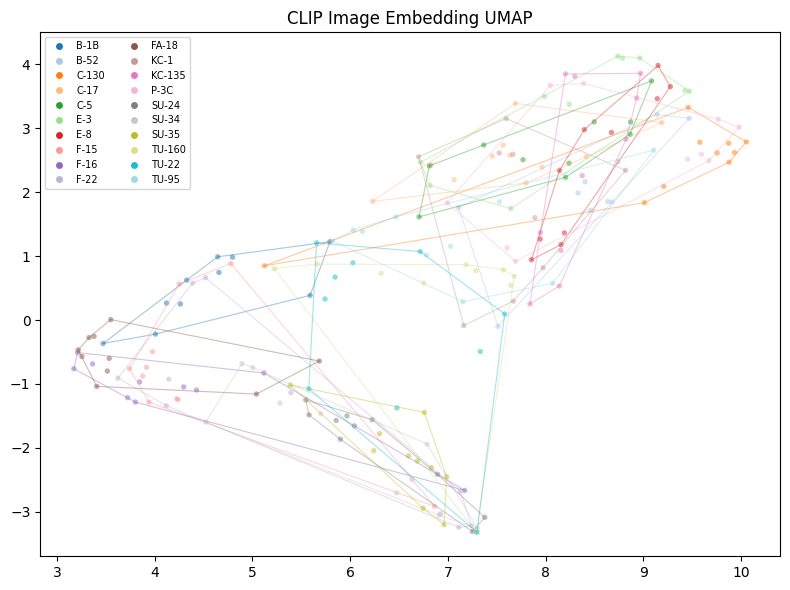

In [68]:
plot_umap_crops(
    clip_crop_embed_list,
    "CLIP Image Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


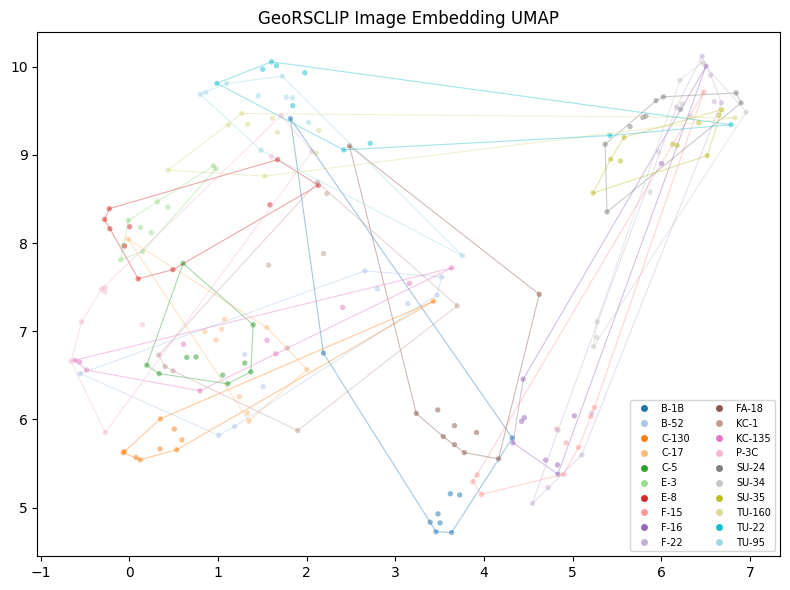

In [69]:
plot_umap_crops(
    georsclip_crop_embed_list,
    "GeoRSCLIP Image Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


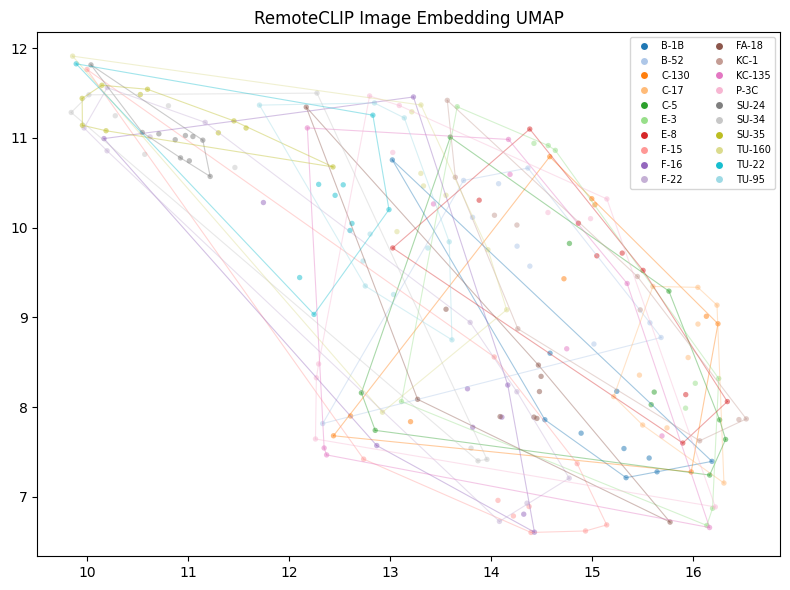

In [70]:
plot_umap_crops(
    remoteclip_crop_embed_list,
    "RemoteCLIP Image Embedding UMAP",
    label_names
)

In [71]:
from sklearn.metrics import silhouette_score
C, S, D = clip_crop_embed_list.shape
score = silhouette_score(clip_crop_embed_list.detach().cpu().float().reshape(-1, D).numpy(), np.repeat(np.arange(C), S), metric="cosine")
print(f"Silhouette score: {score:.3f}")

C, S, D = georsclip_crop_embed_list.shape
score = silhouette_score(georsclip_crop_embed_list.detach().cpu().float().reshape(-1, D).numpy(), np.repeat(np.arange(C), S), metric="cosine")
print(f"Silhouette score: {score:.3f}")

C, S, D = remoteclip_crop_embed_list.shape
score = silhouette_score(remoteclip_crop_embed_list.detach().cpu().float().reshape(-1, D).numpy(), np.repeat(np.arange(C), S), metric="cosine")
print(f"Silhouette score: {score:.3f}")

Silhouette score: -0.045
Silhouette score: -0.055
Silhouette score: -0.103


In [73]:
def plot_class_similarity(crop_embed, class_names=None):
    crop_embed = F.normalize(crop_embed.detach().cpu().float(), dim=-1)
    C, S, D = crop_embed.shape
    labels = class_names if class_names else [str(i) for i in range(C)]

    # (C, D) mean embeddings, compute CxC similarity matrix
    crop_mean = crop_embed.mean(dim=1)
    sim_matrix = (crop_mean @ crop_mean.T).numpy()

    fig, ax = plt.subplots(figsize=(max(6, C*0.5), max(6, C*0.5)))
    im = ax.imshow(sim_matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(C)); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(C)); ax.set_yticklabels(labels, fontsize=7)
    plt.colorbar(im, ax=ax)
    ax.set_title("Inter-class cosine similarity (mean embeddings)")
    plt.tight_layout(); plt.show()